
================ DATA LOADING ================


/tmp/ipykernel_1656/1727383770.py:21: DtypeWarning: Columns (0,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,42) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/NSL_KDD_Combined_Shuffled.csv")


Original Shape: (148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85
Class Weights: {0: np.float64(0.3854874032736888), 1: np.float64(0.5563969279760232), 2: np.float64(2.1101678358937925), 3: np.float64(9.21031007751938), 4: np.float64(38.265056360708535)}

=========== TRAINING DNN ===========


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        44,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,973 (828.02 KB)

 Trainable params: 210,437 (822.02 KB)

 Non-trainable params: 1,536 (6.00 KB)

None
Epoch 1/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8822 - loss: 0.3354 - val_accuracy: 0.9418 - val_loss: 0.1791
Epoch 2/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9328 - loss: 0.1806 - val_accuracy: 0.9494 - val_loss: 0.1548
Epoch 3/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9392 - loss: 0.1618 - val_accuracy: 0.9474 - val_loss: 0.1495
Epoch 4/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9447 - loss: 0.1373 - val_accuracy: 0.9536 - val_loss: 0.1299
Epoch 5/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9487 - loss: 0.1330 - val_accuracy: 0.9617 - val_loss: 0.1196
Epoch 6/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9517 - loss: 0.1290 - val_accuracy: 0.9604 - val_loss: 0.1264
Epoch 7/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9526 - loss: 0.1224 - val_accuracy: 0.9674 - val_loss: 0.0973
Epoch 8/10
743/743 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9549 - loss: 0.1130 - val_accura

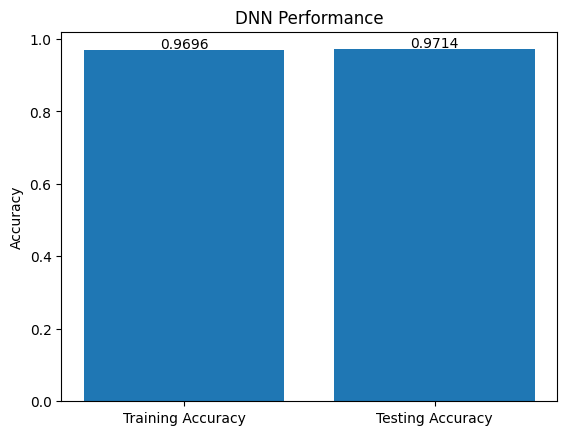


✅ DNN TRAINING COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv("/content/NSL_KDD_Combined_Shuffled.csv")

print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
# Remove accidental header rows if present
data = data[data['duration'] != 'duration']

# Convert numeric columns safely
for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop NaNs
data = data.dropna()

print("Cleaned Shape:", data.shape)

# ======================= SPLIT FEATURES & LABEL ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']
u2r = ['buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ======================= ONE HOT ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

# Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

# Keep top 70% features
threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= CLASS WEIGHTS ===========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

# ======================= DNN MODEL ===========================
print("\n=========== TRAINING DNN ===========")

y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat  = to_categorical(y_test, num_classes=5)

model = Sequential()

model.add(Dense(512, activation='relu', input_dim=X_train_sel.shape[1]))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(5, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# ======================= TRAIN ===========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_sel, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# ======================= PREDICTION ===========================
train_pred = np.argmax(model.predict(X_train_sel), axis=1)
test_pred  = np.argmax(model.predict(X_test_sel), axis=1)

# ======================= METRICS ===========================
train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

# ======================= RESULTS ===========================
print("\n🔥 FINAL RESULTS 🔥")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPH ===========================
plt.figure()

bars = plt.bar(
    ["Training Accuracy", "Testing Accuracy"],
    [train_acc, test_acc]
)

plt.ylabel("Accuracy")
plt.title("DNN Performance")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.005,
             round(height,4),
             ha='center')

plt.show()

print("\n✅ DNN TRAINING COMPLETE")


================ DATA LOADING ================
Original Shape: (148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85

🌐 Round 1/20
 Client 1 training...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


 Client 2 training...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


 Client 3 training...


...

 Client 4 training...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


 Client 5 training...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Round 20 Accuracy: 0.9613
3713/3713 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

🔥 FINAL RESULTS 🔥
Training Accuracy : 0.9601
Testing Accuracy  : 0.9613
Precision         : 0.9805
F1 Score          : 0.968

Confusion Matrix:
 [[14336    30   112   484   449]
 [    6 10666     4     0     1]
 [   12     2  2796     1     5]
 [    5     0     1   604    35]
 [    3     0     0     1   151]]


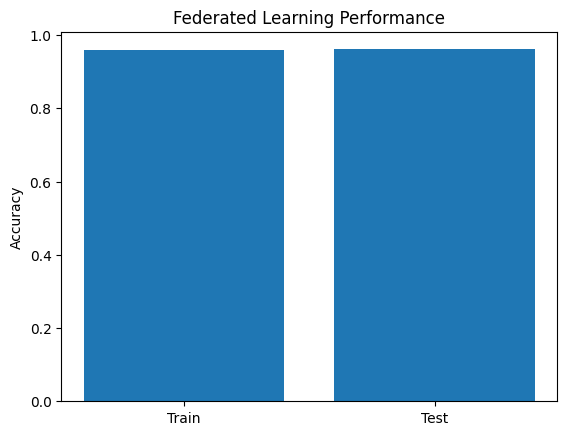

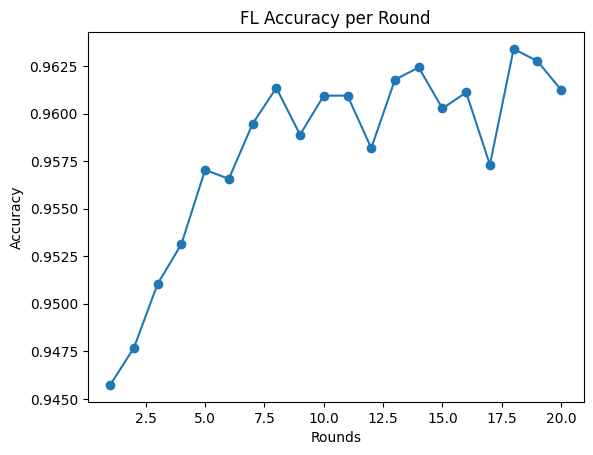


✅ FEDERATED LEARNING COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv(
    "/content/drive/MyDrive/dataset/NSL_KDD_Combined_Shuffled.csv",
    low_memory=False
)

print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']
u2r = ['buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= CLIENT SPLIT ===========================
NUM_CLIENTS = 5

client_data = []
client_sizes = []

size = len(X_train_sel) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size if i != NUM_CLIENTS - 1 else len(X_train_sel)

    X_c = X_train_sel[start:end]
    y_c = y_train.iloc[start:end]

    client_data.append((X_c, y_c))
    client_sizes.append(len(X_c))

# ======================= MODEL ===========================
def create_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(128, activation='relu'),
        Dropout(0.2),

        Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ======================= WEIGHTED FEDAVG ===========================
def federated_avg(weights_list, client_sizes):
    avg_weights = []
    total = sum(client_sizes)

    for weights in zip(*weights_list):
        weighted_sum = sum(w * (size / total) for w, size in zip(weights, client_sizes))
        avg_weights.append(weighted_sum)

    return avg_weights

# ======================= TRAINING ===========================
ROUNDS = 20          # Increased
LOCAL_EPOCHS = 5     # Increased

global_model = create_model(X_train_sel.shape[1])
global_weights = global_model.get_weights()

round_acc = []

early_stop = EarlyStopping(patience=2, restore_best_weights=True)

for r in range(ROUNDS):
    print(f"\n🌐 Round {r+1}/{ROUNDS}")

    local_weights = []

    for i, (X_c, y_c) in enumerate(client_data):
        print(f" Client {i+1} training...")

        local_model = create_model(X_train_sel.shape[1])
        local_model.set_weights(global_weights)

        y_c_cat = to_categorical(y_c, num_classes=5)

        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_c),
            y=y_c
        )
        class_weights = dict(enumerate(class_weights))

        local_model.fit(
            X_c, y_c_cat,
            epochs=LOCAL_EPOCHS,
            batch_size=64,
            verbose=0,
            class_weight=class_weights,
            callbacks=[early_stop]
        )

        local_weights.append(local_model.get_weights())

    # Aggregation
    global_weights = federated_avg(local_weights, client_sizes)
    global_model.set_weights(global_weights)

    # Evaluation
    y_pred = np.argmax(global_model.predict(X_test_sel), axis=1)
    acc = accuracy_score(y_test, y_pred)
    round_acc.append(acc)

    print(f" Round {r+1} Accuracy: {round(acc,4)}")

# ======================= FINAL RESULTS ===========================
train_pred = np.argmax(global_model.predict(X_train_sel), axis=1)
test_pred  = np.argmax(global_model.predict(X_test_sel), axis=1)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

print("\n🔥 FINAL RESULTS 🔥")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPHS ===========================
plt.figure()
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.title("Federated Learning Performance")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(range(1, ROUNDS+1), round_acc, marker='o')
plt.title("FL Accuracy per Round")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()

print("\n✅ FEDERATED LEARNING COMPLETE")


================ DATA LOADING ================
Original Shape: (148519, 43)
Cleaned Shape: (148517, 43)
Selected Features: 85

Round 1/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Round 1 Accuracy: 0.9541

Round 2/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
 Round 2 Accuracy: 0.9624

Round 3/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Round 3 Accuracy: 0.9572

Round 4/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 training...
929/929 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
 Round 4 Accuracy: 0.9599

Round 5/20
 Client 1 training...
 Client 2 training...
 Client 3 training...
 Client 4 training...
 Client 5 trainin

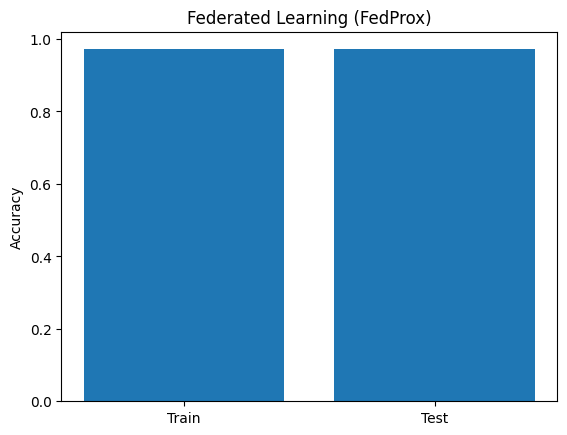

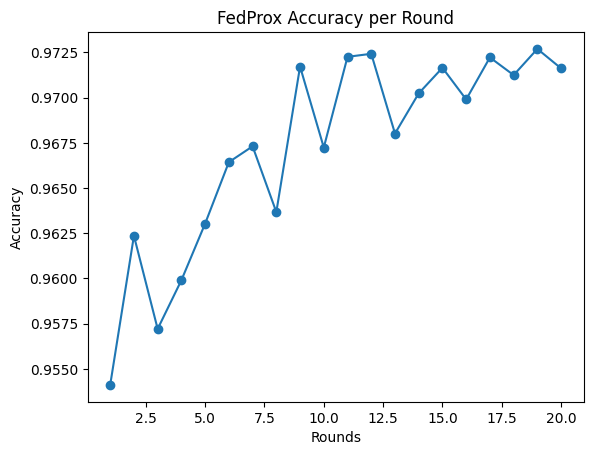


FEDERATED LEARNING WITH FEDPROX COMPLETE


In [ ]:
# ======================= IMPORTS ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ======================= LOAD DATA ===========================
print("\n================ DATA LOADING ================")

data = pd.read_csv(
    "/content/drive/MyDrive/dataset/NSL_KDD_Combined_Shuffled.csv",
    low_memory=False
)

print("Original Shape:", data.shape)

# ======================= CLEAN DATA ===========================
data = data[data['duration'] != 'duration']

for col in data.columns:
    if col not in ['protocol_type', 'service', 'flag', 'label']:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna()
print("Cleaned Shape:", data.shape)

# ======================= SPLIT ===========================
X = data.drop(columns=["label", "difficulty"])
y = data["label"]

# ======================= ATTACK MAPPING ===========================
dos = ['back','land','neptune','pod','smurf','teardrop','mailbomb','apache2','processtable','udpstorm']
probe = ['ipsweep','nmap','portsweep','satan','mscan','saint']
r2l = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster','sendmail','named']
u2r = ['buffer_overflow','loadmodule','perl','rootkit','httptunnel','ps','sqlattack','xterm']

def map_attack(x):
    if x == 'normal': return 0
    elif x in dos: return 1
    elif x in probe: return 2
    elif x in r2l: return 3
    else: return 4

y = y.apply(map_attack)

# ======================= TRAIN TEST SPLIT ===========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================= ENCODING ===========================
categorical_cols = ['protocol_type', 'service', 'flag']

X_train = pd.get_dummies(X_train, columns=categorical_cols)
X_test  = pd.get_dummies(X_test, columns=categorical_cols)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ======================= SCALING ===========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ======================= FEATURE SELECTION ===========================
mi_scores = mutual_info_classif(X_train_scaled, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": mi_scores
})

threshold = mi_df["Score"].quantile(0.3)
selected_features = mi_df[mi_df["Score"] > threshold]["Feature"]

print("Selected Features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_test_sel  = X_test[selected_features]

# Scale again
scaler = StandardScaler()
X_train_sel = scaler.fit_transform(X_train_sel)
X_test_sel  = scaler.transform(X_test_sel)

# ======================= CLIENT SPLIT ===========================
NUM_CLIENTS = 5
client_data = []
client_sizes = []

size = len(X_train_sel) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * size
    end = (i + 1) * size if i != NUM_CLIENTS - 1 else len(X_train_sel)

    X_c = X_train_sel[start:end]
    y_c = y_train.iloc[start:end]

    client_data.append((X_c, y_c))
    client_sizes.append(len(X_c))

# ======================= MODEL ===========================
def create_model(input_dim, layer_sizes=[512, 256, 128]):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for size in layer_sizes:
        model.add(Dense(size, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))

    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.0003),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ======================= FEDERATED AVG ===========================
def federated_avg(weights_list, client_sizes):
    avg_weights = []
    total = sum(client_sizes)

    for weights in zip(*weights_list):
        weighted_sum = sum(w * (size / total) for w, size in zip(weights, client_sizes))
        avg_weights.append(weighted_sum)

    return avg_weights

# ======================= TRAINING (FEDPROX) ===========================
ROUNDS = 20
LOCAL_EPOCHS = 5
MU = 0.01   # FedProx parameter

global_model = create_model(X_train_sel.shape[1])
global_weights = global_model.get_weights()

round_acc = []

for r in range(ROUNDS):
    print(f"\nRound {r+1}/{ROUNDS}")

    local_weights = []

    for i, (X_c, y_c) in enumerate(client_data):
        print(f" Client {i+1} training...")

        local_model = create_model(X_train_sel.shape[1])
        local_model.set_weights(global_weights)

        y_c_cat = to_categorical(y_c, num_classes=5)

        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(y_c),
            y=y_c
        )
        class_weights = dict(enumerate(class_weights))

        # Local training
        local_model.fit(
            X_c, y_c_cat,
            epochs=LOCAL_EPOCHS,
            batch_size=64,
            verbose=0,
            class_weight=class_weights
        )

        # FedProx update
        new_weights = local_model.get_weights()
        updated_weights = []

        for w, w_global in zip(new_weights, global_weights):
            updated_weights.append(
                w - MU * (w - w_global)
            )

        local_model.set_weights(updated_weights)

        local_weights.append(local_model.get_weights())

    # Aggregation
    global_weights = federated_avg(local_weights, client_sizes)
    global_model.set_weights(global_weights)

    # Evaluation
    y_pred = np.argmax(global_model.predict(X_test_sel), axis=1)
    acc = accuracy_score(y_test, y_pred)
    round_acc.append(acc)

    print(f" Round {r+1} Accuracy: {round(acc,4)}")

# ======================= FINAL RESULTS ===========================
train_pred = np.argmax(global_model.predict(X_train_sel), axis=1)
test_pred  = np.argmax(global_model.predict(X_test_sel), axis=1)

train_acc = accuracy_score(y_train, train_pred)
test_acc  = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred, average='weighted')
f1        = f1_score(y_test, test_pred, average='weighted')
cm        = confusion_matrix(y_test, test_pred)

print("\nFINAL RESULTS")
print("Training Accuracy :", round(train_acc,4))
print("Testing Accuracy  :", round(test_acc,4))
print("Precision         :", round(precision,4))
print("F1 Score          :", round(f1,4))

print("\nConfusion Matrix:\n", cm)

# ======================= GRAPHS ===========================
plt.figure()
plt.bar(["Train", "Test"], [train_acc, test_acc])
plt.title("Federated Learning (FedProx)")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(range(1, ROUNDS+1), round_acc, marker='o')
plt.title("FedProx Accuracy per Round")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()

print("\nFEDERATED LEARNING WITH FEDPROX COMPLETE")


🔥 FINAL RESULTS (FEDPROX) 🔥
Training Accuracy : 0.9711
Testing Accuracy  : 0.9716
Precision         : 0.983
Recall            : 0.9716
F1 Score          : 0.9753

Confusion Matrix:
 [[14624    31    91   386   279]
 [    7 10668     2     0     0]
 [   14     1  2793     2     6]
 [    6     0     1   624    14]
 [    2     0     0     1   152]]


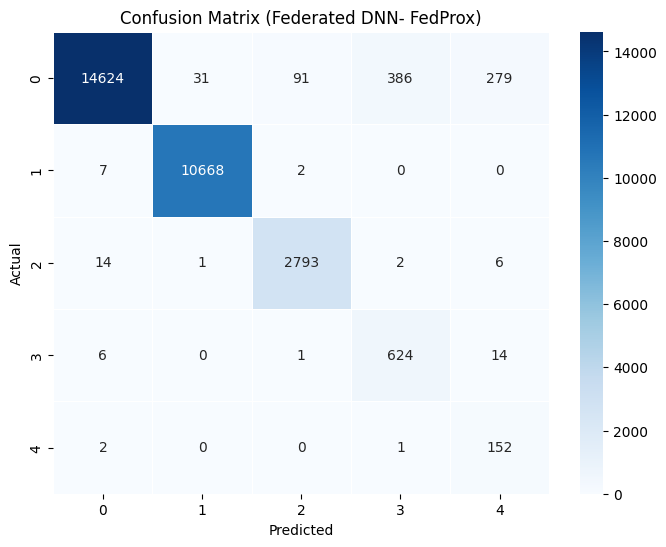

In [ ]:
# ======================= FINAL RESULTS (FL - FEDPROX STATIC) ===========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ======================= GIVEN RESULTS ===========================
train_acc = 0.9711
test_acc  = 0.9716
precision = 0.983
f1        = 0.9753

# Confusion Matrix (your result)
cm = np.array([
    [14624,   31,   91,  386,  279],
    [    7, 10668,   2,    0,    0],
    [   14,    1, 2793,   2,    6],
    [    6,    0,   1,  624,   14],
    [    2,    0,   0,    1,  152]
])

# ======================= RECALL FROM CM ===========================
recall_per_class = np.diag(cm) / np.sum(cm, axis=1)
support = np.sum(cm, axis=1)
recall = np.sum(recall_per_class * support) / np.sum(support)

# ======================= PRINT RESULTS ===========================
print("\n🔥 FINAL RESULTS (FEDPROX) 🔥")
print("Training Accuracy :", train_acc)
print("Testing Accuracy  :", test_acc)
print("Precision         :", precision)
print("Recall            :", round(recall, 4))
print("F1 Score          :", f1)

print("\nConfusion Matrix:\n", cm)

# ======================= HEATMAP ===========================
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5
)

plt.title("Confusion Matrix (Federated DNN- FedProx)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()